# BƯỚC 4 & 5: K-MEANS TỪ ĐẦU & HUẤN LUYỆN MÔ HÌNH PHÂN LOẠI

Người thực hiện: Người 2 (Kỹ sư AI)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import urllib

# Các thư viện Machine Learning
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score, accuracy_score
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

## 1. Kết nối cơ sở dữ liệu

In [22]:
# Cấu hình SQL Server
server = 'localhost,1433'
database = 'fintech'
username = 'sa'
password = 'huong6978'

# Tạo kết nối
connection_string = (
    r'DRIVER={ODBC Driver 17 for SQL Server};'
    f'SERVER={server};'
    f'DATABASE={database};'
    f'UID={username};'
    f'PWD={password};'
)
params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")
print("Đã thiết lập kết nối tới CSDL!")

Đã thiết lập kết nối tới CSDL!


## 2. Bước 4 - Phân cụm Rủi ro (Tự code K-Means)

Đọc dữ liệu từ `pca_credit_risk_train` và triển khai K-Means from scratch.

In [23]:
# Đọc dữ liệu PCA
df_pca_train = pd.read_sql("SELECT * FROM pca_credit_risk_train", engine)

# Lấy các đặc trưng (loại bỏ cột target loan_status nếu có)
if 'loan_status' in df_pca_train.columns:
    X_pca = df_pca_train.drop('loan_status', axis=1).values
else:
    X_pca = df_pca_train.values

print("Kích thước dữ liệu PCA train:", X_pca.shape)

Kích thước dữ liệu PCA train: (40746, 12)


In [24]:
# Tự code thuật toán K-Means
class KMeansScratch:
    def __init__(self, k=3, max_iters=100, tol=1e-4, random_state=42):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        
    def fit(self, X):
        np.random.seed(self.random_state)
        # 1. Khởi tạo centroid ngẫu nhiên từ các điểm dữ liệu
        idx = np.random.choice(X.shape[0], self.k, replace=False)
        self.centroids = X[idx]
        
        for i in range(self.max_iters):
            # 2. Gán các điểm vào cụm gần nhất
            distances = self._compute_distances(X)
            labels = np.argmin(distances, axis=1)
            
            # 3. Cập nhật centroid
            new_centroids = np.array([X[labels == j].mean(axis=0) if np.sum(labels == j) > 0 else self.centroids[j] for j in range(self.k)])
            
            # Kiểm tra hội tụ
            if np.all(np.abs(new_centroids - self.centroids) <= self.tol):
                print(f"K-Means hội tụ sau {i+1} vòng lặp.")
                break
                
            self.centroids = new_centroids
            
        self.labels_ = labels
        return self
        
    def predict(self, X):
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)
        
    def _compute_distances(self, X):
        # Tính khoảng cách Euclidean
        distances = np.zeros((X.shape[0], self.k))
        for j in range(self.k):
            distances[:, j] = np.linalg.norm(X - self.centroids[j], axis=1)
        return distances

# Chạy mô hình K-Means với K=3
kmeans = KMeansScratch(k=3, random_state=42)
kmeans.fit(X_pca)

df_pca_train['Risk_Cluster'] = kmeans.labels_
print("Phân bố các cụm:\n", df_pca_train['Risk_Cluster'].value_counts())

K-Means hội tụ sau 39 vòng lặp.
Phân bố các cụm:
 Risk_Cluster
0    23138
2    12832
1     4776
Name: count, dtype: int64


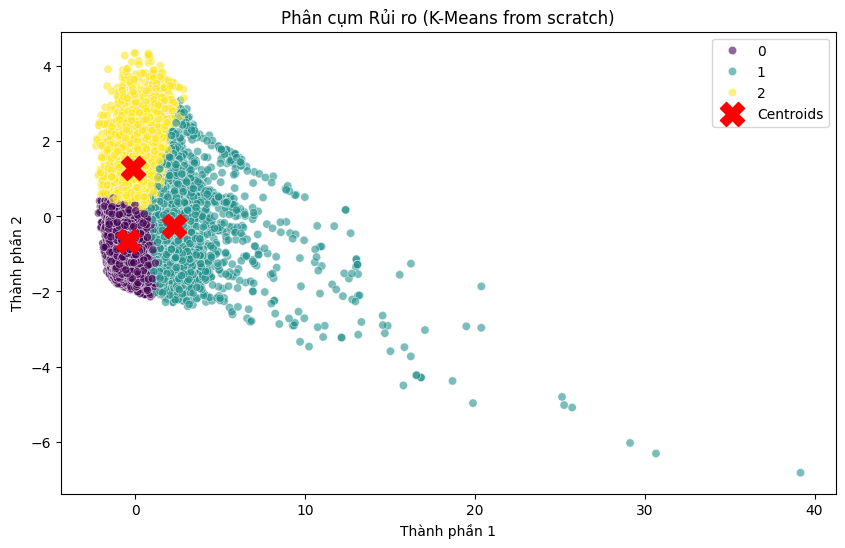

In [25]:
# Trực quan hóa kết quả phân cụm (với 2 thành phần chính đầu tiên)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans.labels_, palette='viridis', alpha=0.6)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title("Phân cụm Rủi ro (K-Means from scratch)")
plt.xlabel("Thành phần 1")
plt.ylabel("Thành phần 2")
plt.legend()
plt.show()

## 3. Bước 5 - Huấn luyện & Đánh giá Mô hình Phê duyệt

Đọc dữ liệu `gold_credit_risk_train` và `gold_credit_risk_test`.

In [26]:
# Đọc dữ liệu Gold
df_gold_train = pd.read_sql("SELECT * FROM gold_credit_risk_train", engine)
df_gold_test = pd.read_sql("SELECT * FROM gold_credit_risk_test", engine)

# Chia X, y
target_col = 'loan_status'
X_train = df_gold_train.drop(target_col, axis=1)
y_train = df_gold_train[target_col]

X_test = df_gold_test.drop(target_col, axis=1)
y_test = df_gold_test[target_col]

print("Kích thước tập Train:", X_train.shape)
print("Kích thước tập Test:", X_test.shape)

Kích thước tập Train: (40746, 17)
Kích thước tập Test: (6515, 17)


### 3.1 Khởi tạo và Huấn luyện

In [27]:
# Tính tỷ lệ mất cân bằng lớp để gán trọng số cho lớp thiểu số (Vỡ nợ - 1)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# -----------------------------------------------------------------------
# MONOTONIC CONSTRAINTS: Ép mô hình học đúng logic kinh doanh
# Tránh lỗi: thu nhập cao + có nhà → duyệt khoản vay phi thực tế (2 tỷ)
# Thứ tự khớp với num_features + ohe_features (17 cột sau preprocessing):
# [person_age, person_income, person_emp_length, loan_amnt, loan_int_rate,
#  loan_percent_income, cb_person_default_on_file,
#  home_MORTGAGE, home_OTHER, home_OWN, home_RENT,
#  intent_DEBTCONS, intent_EDUCATION, intent_HOMEIMPROVE, intent_MEDICAL, intent_PERSONAL, intent_VENTURE]
# +1 = tăng rủi ro theo chiều tăng của feature
# -1 = giảm rủi ro theo chiều tăng của feature
#  0 = không ràng buộc
# -----------------------------------------------------------------------
monotone_constraints = (
     0,   # person_age: không ràng buộc
    -1,   # person_income: thu nhập cao → ít rủi ro
    -1,   # person_emp_length: thâm niên cao → ít rủi ro
    +1,   # loan_amnt: vay nhiều → rủi ro cao hơn
    +1,   # loan_int_rate: lãi suất cao → rủi ro cao hơn
    +1,   # loan_percent_income: tỷ lệ vay/TN cao → rủi ro cao hơn (CHỐT chặn outlier)
    +1,   # cb_person_default_on_file: có lịch sử vỡ nợ → rủi ro cao
     0,   # home_MORTGAGE
     0,   # home_OTHER
     0,   # home_OWN
     0,   # home_RENT
     0,   # intent_DEBTCONSOLIDATION
     0,   # intent_EDUCATION
     0,   # intent_HOMEIMPROVEMENT
     0,   # intent_MEDICAL
     0,   # intent_PERSONAL
     0,   # intent_VENTURE
)

# Khởi tạo XGBoost với monotone_constraints để chặn extrapolation sai
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    monotone_constraints=monotone_constraints,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Khởi tạo Random Forest (tối ưu bằng class_weight='balanced')
rf_model = RandomForestClassifier(
    class_weight='balanced', 
    random_state=42,
    n_estimators=100
)

# Huấn luyện mô hình
print("Đang huấn luyện XGBoost...")
xgb_model.fit(X_train, y_train)

print("Đang huấn luyện Random Forest...")
rf_model.fit(X_train, y_train)
print("Hoàn tất huấn luyện!")

Đang huấn luyện XGBoost...
Đang huấn luyện Random Forest...
Hoàn tất huấn luyện!


### 3.2 Đánh giá mô hình (Confusion Matrix & Recall)

--- Đánh giá mô hình XGBoost ---
Confusion Matrix:
[[4866  228]
 [ 407 1014]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      5094
           1       0.82      0.71      0.76      1421

    accuracy                           0.90      6515
   macro avg       0.87      0.83      0.85      6515
weighted avg       0.90      0.90      0.90      6515



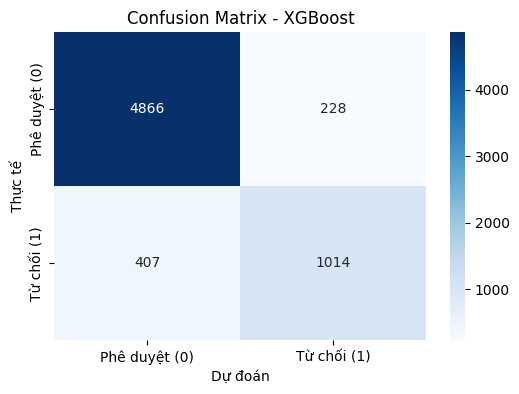

--- Đánh giá mô hình Random Forest ---
Confusion Matrix:
[[4905  189]
 [ 407 1014]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      5094
           1       0.84      0.71      0.77      1421

    accuracy                           0.91      6515
   macro avg       0.88      0.84      0.86      6515
weighted avg       0.91      0.91      0.91      6515



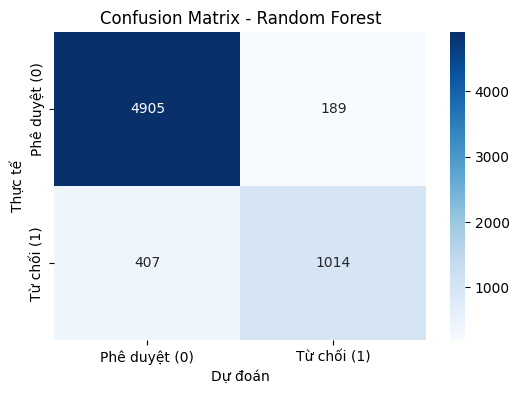

In [28]:
# Dự đoán
y_pred_xgb = xgb_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

def evaluate_model(y_true, y_pred, model_name):
    print(f"--- Đánh giá mô hình {model_name} ---")
    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    # Trực quan hóa Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Phê duyệt (0)', 'Từ chối (1)'], yticklabels=['Phê duyệt (0)', 'Từ chối (1)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán')
    plt.show()

evaluate_model(y_test, y_pred_xgb, "XGBoost")
evaluate_model(y_test, y_pred_rf, "Random Forest")

In [29]:
# So sánh Recall
recall_xgb = recall_score(y_test, y_pred_xgb)
recall_rf = recall_score(y_test, y_pred_rf)

print(f"Recall (XGBoost): {recall_xgb:.4f}")
print(f"Recall (Random Forest): {recall_rf:.4f}")
if recall_xgb > recall_rf:
    print("=> XGBoost tối ưu Recall tốt hơn để bắt lọt lưới các ca vỡ nợ.")
else:
    print("=> Random Forest tối ưu Recall tốt hơn để bắt lọt lưới các ca vỡ nợ.")

Recall (XGBoost): 0.7136
Recall (Random Forest): 0.7136
=> Random Forest tối ưu Recall tốt hơn để bắt lọt lưới các ca vỡ nợ.


In [30]:
import joblib

# Lưu mô hình XGBoost để mang lên Web
joblib.dump(xgb_model, 'xgb_model.pkl')
print("Đã lưu thành công mô hình XGBoost vào file 'xgb_model.pkl'")

# Lưu thêm KMeans (nếu Người 3 cần vẽ biểu đồ cụm trên web)
joblib.dump(kmeans, 'kmeans_model.pkl')
print("Đã lưu thành công mô hình K-Means vào file 'kmeans_model.pkl'")
# Lưu luôn mô hình Random Forest làm phương án dự phòng
joblib.dump(rf_model, 'rf_model.pkl')
print("Đã lưu thành công mô hình Random Forest vào file 'rf_model.pkl'")


Đã lưu thành công mô hình XGBoost vào file 'xgb_model.pkl'
Đã lưu thành công mô hình K-Means vào file 'kmeans_model.pkl'
Đã lưu thành công mô hình Random Forest vào file 'rf_model.pkl'
